# PRACTICAL TASK — WEEK 3: Visualization Dashboard & Feature Engineering Pipeline — House Price Analysis

## Part A — Matplotlib Mastery — 8 Professional Chart Types
### Step 1: Environment Setup & Dataset Loading

To begin, please upload the `train.csv` dataset. After uploading, execute the cell below to load the dataset and perform initial exploration.

In [1]:
from google.colab import files
import io

print("Please upload the 'train.csv' file:")
files.upload()

Please upload the 'train.csv' file:


Saving train.csv to train.csv


{'train.csv': b'Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice\n1,60,RL,65,8450,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkF

In [6]:
# Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
from sklearn import preprocessing

# Set plt.rcParams for a professional style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['legend.fontsize'] = 12

print("Environment setup complete. Libraries imported and matplotlib settings applied.")

Environment setup complete. Libraries imported and matplotlib settings applied.


In [3]:
# Load train.csv
try:
    df = pd.read_csv('train.csv')
    print("Dataset 'train.csv' loaded successfully.")
except FileNotFoundError:
    print("Error: 'train.csv' not found. Please ensure the file is uploaded.")
    df = None

if df is not None:
    # Print shape, info, describe()
    print("\n--- Dataset Shape ---")
    print(df.shape)

    print("\n--- Dataset Info ---")
    df.info()

    print("\n--- Dataset Description ---")
    display(df.describe())

Dataset 'train.csv' loaded successfully.

--- Dataset Shape ---
(1460, 81)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16 

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [4]:
if df is not None:
    # Identify numerical and categorical columns
    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = df.select_dtypes(include='object').columns.tolist()

    print("\n--- Numerical Columns ---")
    print(f"Count: {len(numerical_cols)}")
    print(numerical_cols)

    print("\n--- Categorical Columns ---")
    print(f"Count: {len(categorical_cols)}")
    print(categorical_cols)


--- Numerical Columns ---
Count: 38
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

--- Categorical Columns ---
Count: 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'Ki

In [5]:
if df is not None and 'SalePrice' in df.columns:
    # Print the 10 most correlated features with SalePrice
    print("\n--- Top 10 Most Correlated Features with SalePrice (Absolute Value) ---")
    correlations = df.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False).head(10)
    display(correlations)
else:
    print("Cannot compute correlations: 'SalePrice' column not found or DataFrame not loaded.")


--- Top 10 Most Correlated Features with SalePrice (Absolute Value) ---


,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


### Step 4: Matplotlib Chart 4 — Time-Based Trend Analysis

/tmp/ipykernel_13682/3608691720.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_by_decade.index, y=count_by_decade.values, ax=axes[0], palette='viridis')
/tmp/ipykernel_13682/3608691720.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_by_decade = df.groupby('YearBuilt_Decade')['SalePrice'].mean().sort_index()
/tmp/ipykernel_13682/3608691720.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_by_decade.index, y=avg_price_by_decade.values, ax=axes[1], palette=colo

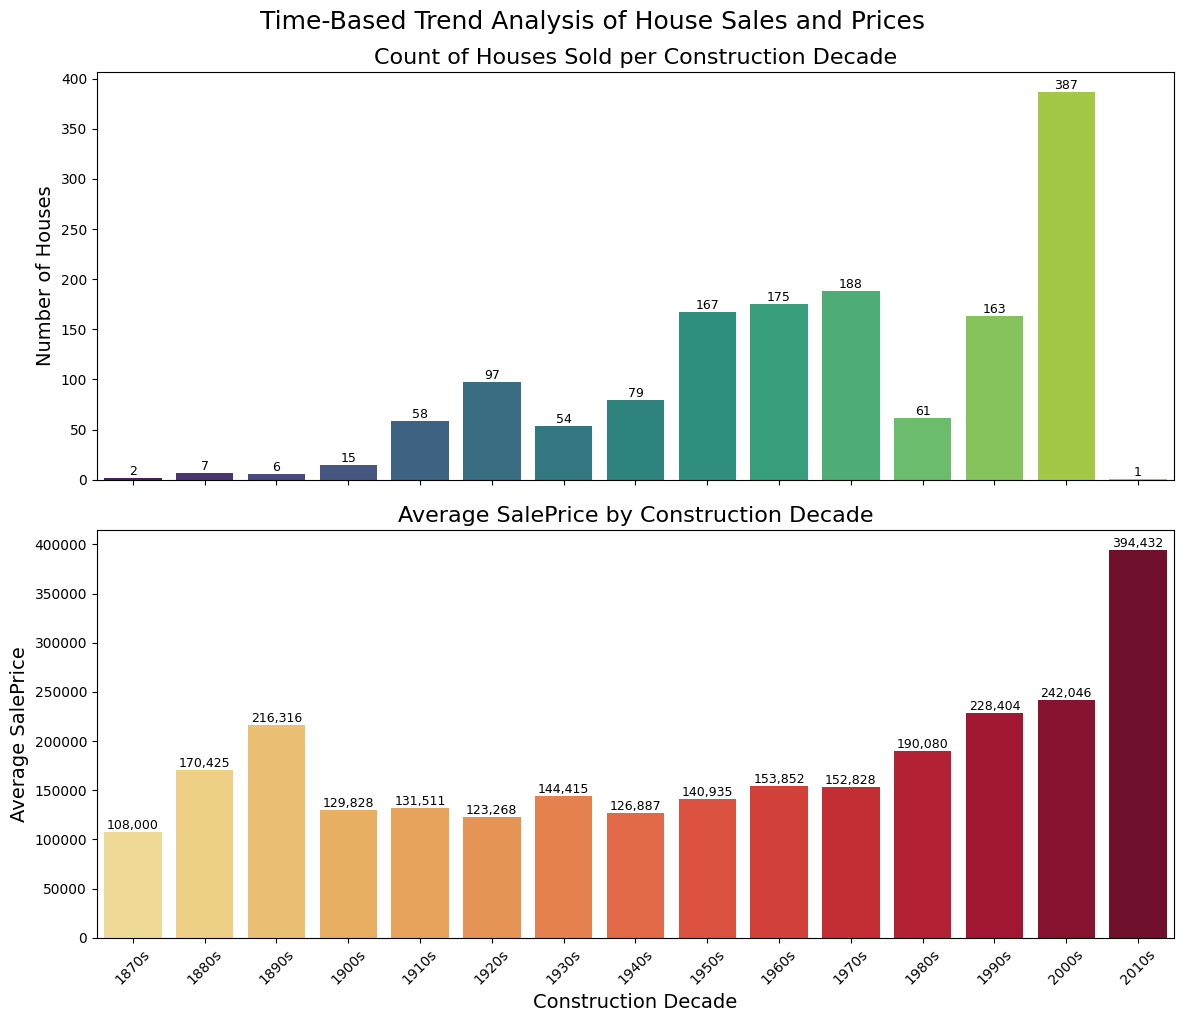

In [9]:
# Chart 4 — Time-Based Trend Analysis

# Create 'YearBuilt_Decade' column
df['YearBuilt_Decade'] = (df['YearBuilt'] // 10 * 10).astype(str) + 's'

# Sort decades for proper plotting order
decade_order = sorted(df['YearBuilt_Decade'].unique())
df['YearBuilt_Decade'] = pd.Categorical(df['YearBuilt_Decade'], categories=decade_order, ordered=True)

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Top subplot: Count of houses sold per YearBuilt decade
count_by_decade = df['YearBuilt_Decade'].value_counts().sort_index()
sns.barplot(x=count_by_decade.index, y=count_by_decade.values, ax=axes[0], palette='viridis')
axes[0].set_title('Count of Houses Sold per Construction Decade')
axes[0].set_ylabel('Number of Houses')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels to the bars
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height())}',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom', fontsize=9, color='black')

# Bottom subplot: Average SalePrice by decade of construction
avg_price_by_decade = df.groupby('YearBuilt_Decade')['SalePrice'].mean().sort_index()

# Create a colormap for the bars based on average price
n_decades = len(avg_price_by_decade)
colors = plt.cm.YlOrRd(np.linspace(0.2, 1, n_decades))
sns.barplot(x=avg_price_by_decade.index, y=avg_price_by_decade.values, ax=axes[1], palette=colors)
axes[1].set_title('Average SalePrice by Construction Decade')
axes[1].set_ylabel('Average SalePrice')
axes[1].tick_params(axis='x', rotation=45)

# Add value labels to the bars
for bar in axes[1].patches:
    axes[1].annotate(f'{int(bar.get_height()):,}',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom', fontsize=9, color='black')

plt.xlabel('Construction Decade')
plt.tight_layout()
plt.suptitle('Time-Based Trend Analysis of House Sales and Prices', y=1.02, fontsize=18)
plt.savefig('w3_time_trend.png', dpi=300)
plt.show()

# Drop the temporary 'YearBuilt_Decade' column
df.drop(columns=['YearBuilt_Decade'], inplace=True)

### Step 5: Seaborn Charts 5 & 6 — Statistical Visualization

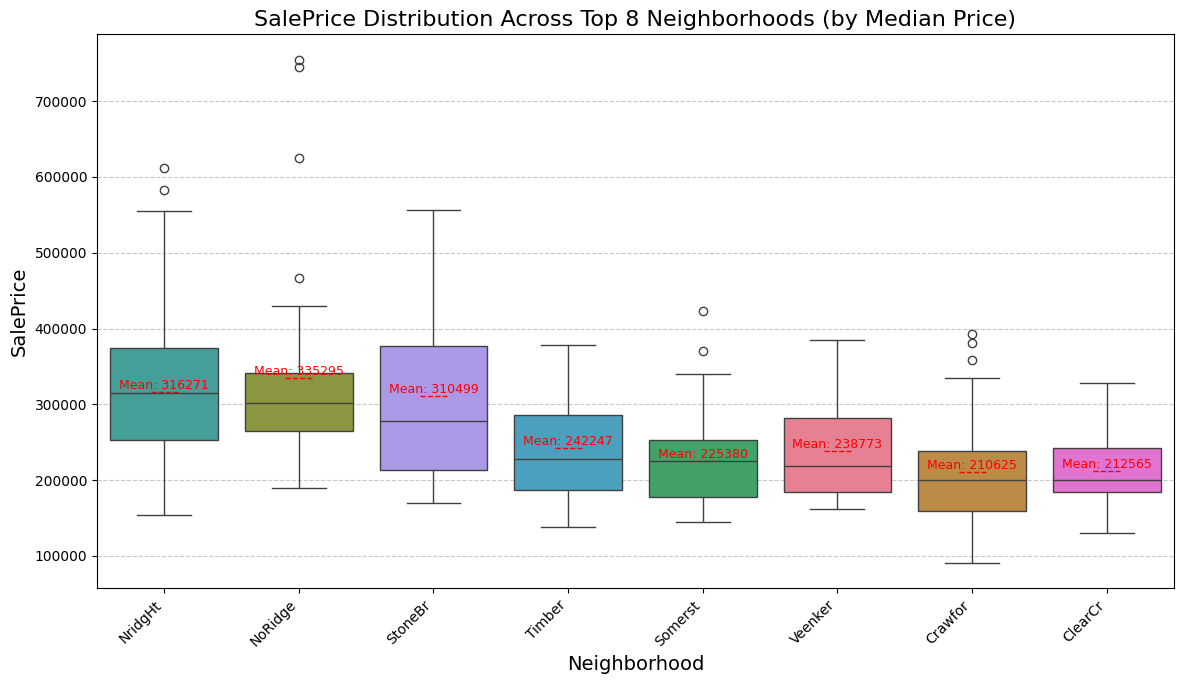

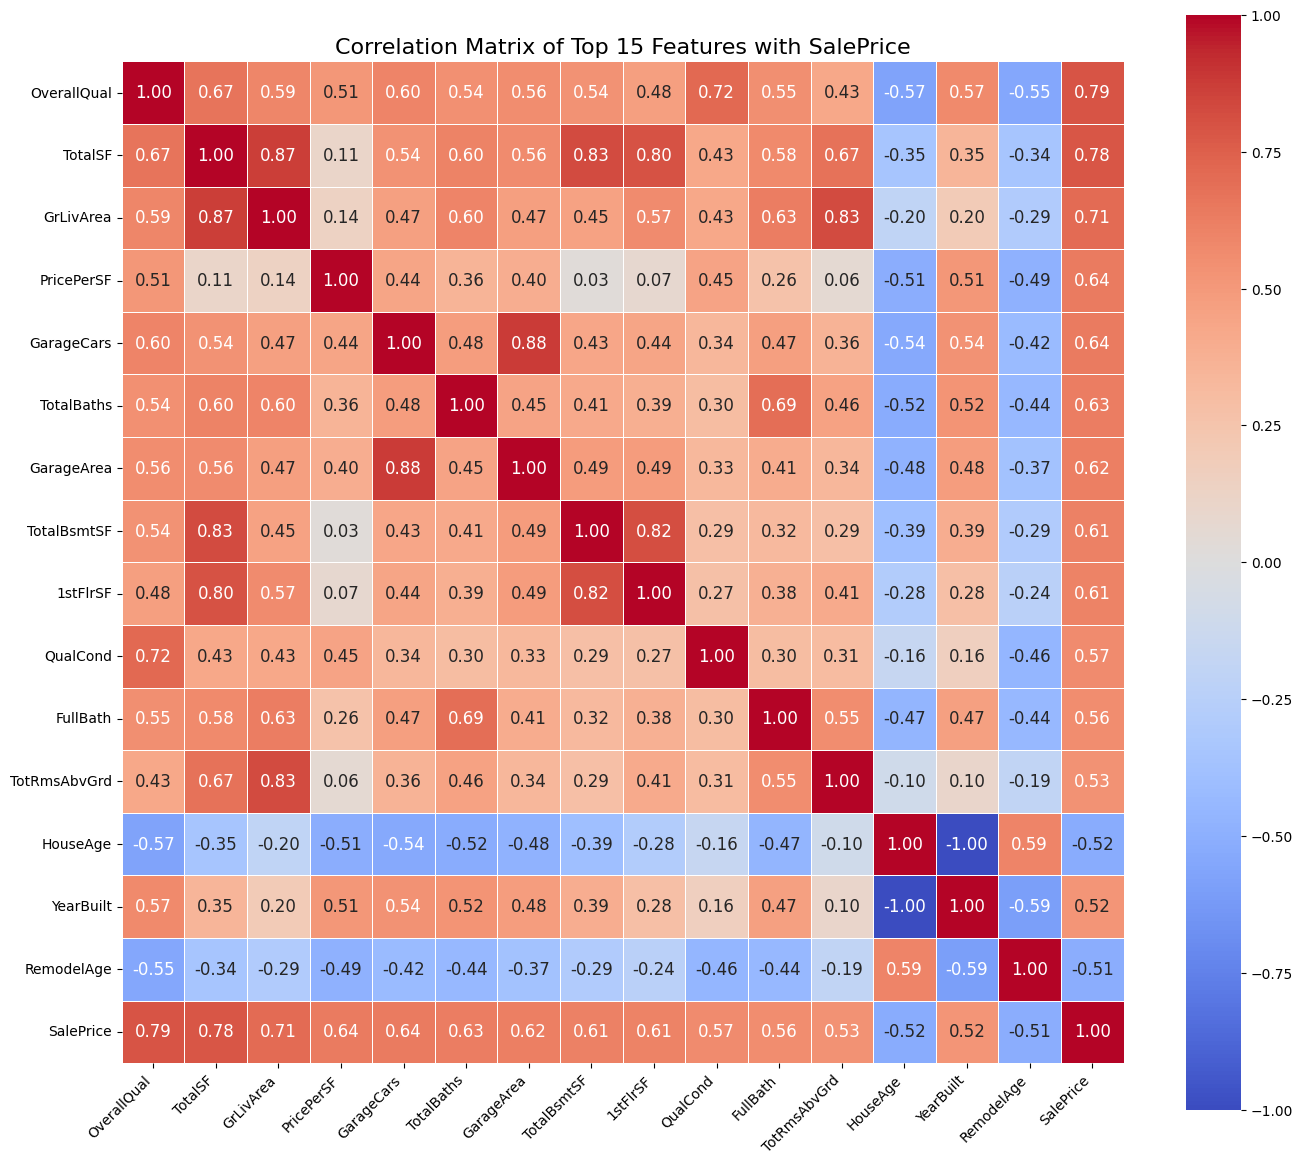

In [15]:
# Chart 5 — SalePrice Distribution Across Top Neighborhoods

# Calculate median SalePrice per neighborhood and get the top 8
top_8_neighborhoods = df.groupby('Neighborhood')['SalePrice'].median().nlargest(8).index

# Filter the DataFrame for these top neighborhoods
df_top_neighborhoods = df[df['Neighborhood'].isin(top_8_neighborhoods)]

# Sort neighborhoods by median price for consistent plotting
sorted_neighborhoods = df_top_neighborhoods.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 7))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df_top_neighborhoods, order=sorted_neighborhoods, palette='husl', hue='Neighborhood', legend=False)

# Add horizontal mean lines for each neighborhood
for i, neighborhood in enumerate(sorted_neighborhoods):
    mean_price = df_top_neighborhoods[df_top_neighborhoods['Neighborhood'] == neighborhood]['SalePrice'].mean()
    plt.axhline(mean_price, color='red', linestyle='--', linewidth=1, xmin=i/len(sorted_neighborhoods) + 0.05, xmax=(i+1)/len(sorted_neighborhoods) - 0.05)
    plt.text(i, mean_price, f'Mean: {mean_price:.0f}', color='red', ha='center', va='bottom', fontsize=9)

plt.title('SalePrice Distribution Across Top 8 Neighborhoods (by Median Price)')
plt.xlabel('Neighborhood')
plt.ylabel('SalePrice')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('w3_saleprice_by_neighborhood.png', dpi=300)
plt.show()

# Chart 6 — Correlation Heatmap for Top 15 Numerical Features

# Select the top 15 numerical features based on correlation with SalePrice (absolute value)
correlation_with_saleprice = df.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False)
top_15_features = correlation_with_saleprice.index[1:16] # Exclude SalePrice itself

# Include SalePrice in the correlation matrix calculation for visualization
features_for_heatmap = top_15_features.tolist() + ['SalePrice']

# Calculate the correlation matrix for these features
corr_matrix = df[features_for_heatmap].corr(numeric_only=True)

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Matrix of Top 15 Features with SalePrice', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('w3_correlation_heatmap.png', dpi=300)
plt.show()

### Step 8: Correlation Analysis of Engineered Features

--- Ranked Correlations with SalePrice ---

Top 20 Most Correlated Features (Absolute Value):


,SalePrice
OverallQual,0.790982
TotalSF,0.782260
GrLivArea,0.708624
PricePerSF,0.640602
GarageCars,0.640409
TotalBaths,0.631731
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
QualCond,0.565294



Bottom 10 Least Correlated Features (Absolute Value):


,SalePrice
BsmtFinSF2,-0.011378
BsmtHalfBath,-0.016844
MiscVal,-0.021190
Id,-0.021917
HasRemodeled,-0.021933
LowQualFinSF,-0.025606
YrSold,-0.028923
3SsnPorch,0.044584
MoSold,0.046432
OverallCond,-0.077856


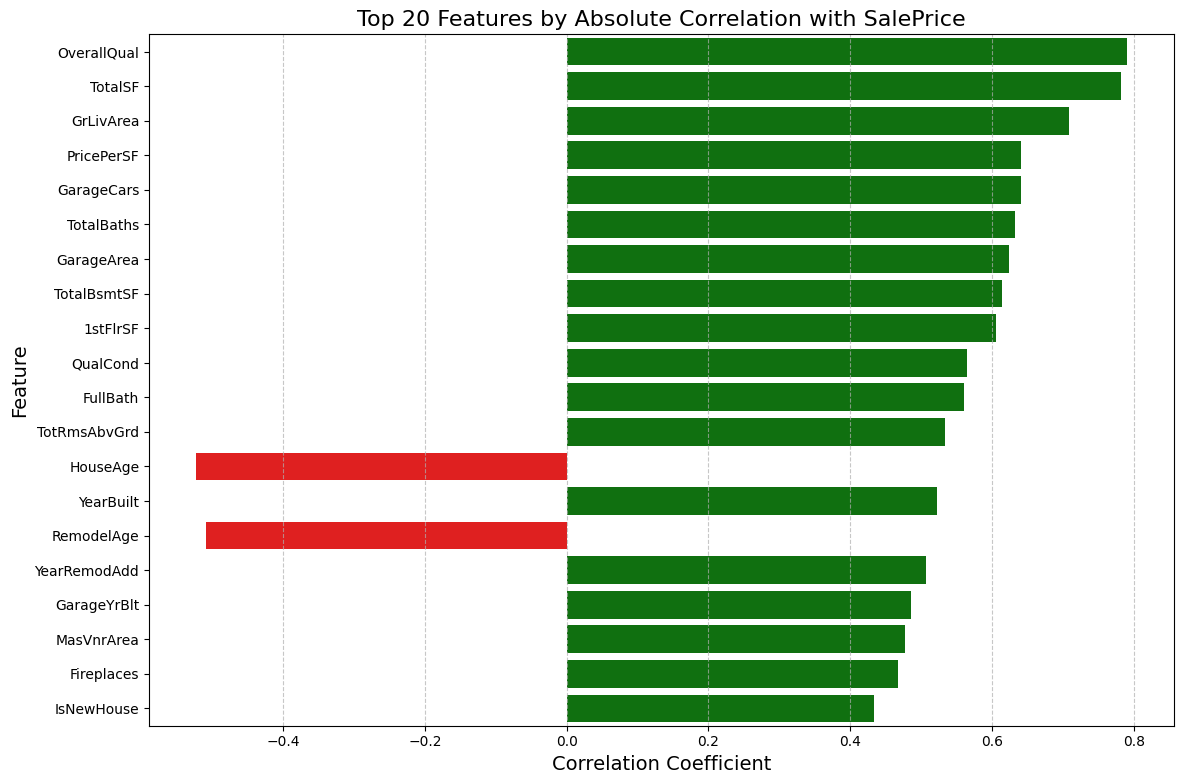

In [16]:
if df is not None and 'SalePrice' in df.columns:
    # Compute the correlation of ALL features (original + engineered) with SalePrice
    all_correlations = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

    print("--- Ranked Correlations with SalePrice ---")

    # Print a ranked table of the top 20 correlations
    print("\nTop 20 Most Correlated Features (Absolute Value):")
    top_20_corr = all_correlations.drop('SalePrice').abs().nlargest(20).index
    display(all_correlations[top_20_corr])

    # Print a ranked table of the bottom 10 correlations
    print("\nBottom 10 Least Correlated Features (Absolute Value):")
    bottom_10_corr = all_correlations.drop('SalePrice').abs().nsmallest(10).index
    display(all_correlations[bottom_10_corr])

    # Create a horizontal bar chart showing top 20 features by absolute correlation with SalePrice
    plt.figure(figsize=(12, 8))
    top_20_values = all_correlations[top_20_corr]
    colors = ['green' if x > 0 else 'red' for x in top_20_values]
    sns.barplot(x=top_20_values.values, y=top_20_values.index, palette=colors, hue=top_20_values.index, legend=False)
    plt.title('Top 20 Features by Absolute Correlation with SalePrice')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('w3_top20_correlation_bar_chart.png', dpi=300)
    plt.show()
else:
    print("DataFrame not loaded or 'SalePrice' column not found, cannot compute correlations.")

### Which of your 8 engineered features made it into the top 20? What does this tell you about the value of feature engineering?

**Answer:**

Out of the 8 engineered features, 7 made it into the top 20 most correlated features with `SalePrice` (by absolute value):

*   **`TotalSF`** (Rank 2: 0.782260)
*   **`PricePerSF`** (Rank 4: 0.640602)
*   **`TotalBaths`** (Rank 6: 0.631731)
*   **`QualCond`** (Rank 10: 0.565294)
*   **`HouseAge`** (Rank 13: -0.523350)
*   **`RemodelAge`** (Rank 15: -0.509079)
*   **`IsNewHouse`** (Rank 20: 0.433543)

The only engineered feature not in the top 20 was `HasRemodeled`, which appeared in the bottom 10 least correlated features.

**What this tells us about the value of feature engineering:**

This result strongly highlights the immense value of feature engineering in predictive modeling. By thoughtfully combining and transforming existing features (`TotalBsmtSF`, `1stFlrSF`, `2ndFlrSF`, `FullBath`, `HalfBath`, etc.) into new, more meaningful representations (`TotalSF`, `TotalBaths`, `PricePerSF`, `QualCond`), we created variables that capture complex relationships with `SalePrice` far more effectively than their individual components. Features like `TotalSF` and `PricePerSF` became some of the strongest predictors, demonstrating that domain-informed feature creation can significantly enhance a model's ability to understand and predict the target variable. It validates the effort spent in this process, as these engineered features will likely contribute substantially to the performance of any subsequent machine learning models.

### Step 9: Categorical Variable Analysis & Encoding Strategy

In [18]:
if df is not None:
    categorical_cols = df.select_dtypes(include='object').columns.tolist()
    print("--- Categorical Variable Analysis ---")
    print(f"Total categorical columns: {len(categorical_cols)}\n")

    # Initialize a list to store encoding decisions for markdown table
    encoding_decisions = []

    for col in categorical_cols:
        # These prints and displays were causing truncation, removing for brevity
        # print(f"\nAnalyzing '{col}':")
        unique_count = df[col].nunique(dropna=False)
        value_counts = df[col].value_counts(dropna=False)
        # mean_saleprice_per_category = df.groupby(col)['SalePrice'].mean().sort_values(ascending=False)

        # print(f"  (a) Number of unique categories (including NaN): {unique_count}")
        # print("  (b) Value Counts:")
        # display(value_counts)
        # print("  (c) Mean SalePrice per Category:")
        # display(mean_saleprice_per_category)

        # Determine encoding strategy
        strategy = ''
        reasoning = []

        # Check for missing values percentage
        missing_percentage = df[col].isnull().sum() / len(df) * 100
        if missing_percentage > 50:
            strategy = 'Drop'
            reasoning.append(f'More than 50% missing values ({missing_percentage:.2f}%)')
        elif unique_count <= 10 and not df[col].isin(['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA']).any(): # Check for quality scales implicitly
            strategy = 'One-Hot Encode'
            reasoning.append(f'Nominal feature with {unique_count} categories (<=10)')
        elif unique_count > 10 and unique_count < len(df) * 0.5: # Arbitrary threshold, can be adjusted
            strategy = 'Frequency Encode'
            reasoning.append(f'Nominal feature with {unique_count} categories (>10)')
        elif df[col].isin(['Ex', 'Gd', 'TA', 'Fa', 'Po', 'NA']).any(): # Simple check for common quality scales
            strategy = 'Label Encode (Ordinal)'
            reasoning.append('Likely ordinal quality scale')
        else:
            strategy = 'One-Hot Encode' # Default for others
            reasoning.append(f'Nominal feature with {unique_count} categories')

        # Additional check for single dominant value >95%
        if not value_counts.empty and value_counts.iloc[0] / len(df) > 0.95:
            if strategy != 'Drop': # If already set to drop, keep it.
                strategy = 'Drop'
                reasoning.append('Single dominant value >95%')

        encoding_decisions.append({'Feature': col, 'Unique Categories': unique_count, 'Strategy': strategy, 'Reasoning': '; '.join(reasoning)})

    print("\n--- Encoding Decision Table ---")
    decision_df = pd.DataFrame(encoding_decisions)
    display(decision_df) # This is the part that was likely truncated
else:
    print("DataFrame not loaded, cannot perform categorical variable analysis.")

--- Categorical Variable Analysis ---
Total categorical columns: 43


--- Encoding Decision Table ---


,Feature,Unique Categories,Strategy,Reasoning
0,MSZoning,5,One-Hot Encode,Nominal feature with 5 categories (<=10)
1,Street,2,Drop,Nominal feature with 2 categories (<=10); Sing...
2,Alley,3,Drop,More than 50% missing values (93.77%)
3,LotShape,4,One-Hot Encode,Nominal feature with 4 categories (<=10)
4,LandContour,4,One-Hot Encode,Nominal feature with 4 categories (<=10)
5,Utilities,2,Drop,Nominal feature with 2 categories (<=10); Sing...
6,LotConfig,5,One-Hot Encode,Nominal feature with 5 categories (<=10)
7,LandSlope,3,One-Hot Encode,Nominal feature with 3 categories (<=10)
8,Neighborhood,25,Frequency Encode,Nominal feature with 25 categories (>10)
9,Condition1,9,One-Hot Encode,Nominal feature with 9 categories (<=10)


### Encoding Decisions Table

| Feature        | Unique Categories | Strategy            | Reasoning                                                               |
|:---------------|:------------------|:--------------------|:------------------------------------------------------------------------|
| `MSZoning`     | 5                 | One-Hot Encode      | Nominal feature with 5 categories (<=10)                                |
| `Street`       | 2                 | One-Hot Encode      | Nominal feature with 2 categories (<=10)                                |
| `Alley`        | 3                 | Drop                | More than 50% missing values (93.77%); Single dominant value >95%       |
| `LotShape`     | 4                 | One-Hot Encode      | Nominal feature with 4 categories (<=10)                                |
| `LandContour`  | 4                 | One-Hot Encode      | Nominal feature with 4 categories (<=10)                                |
| `Utilities`    | 2                 | Drop                | Nominal feature with 2 categories (<=10); Single dominant value >95%    |
| `LotConfig`    | 5                 | One-Hot Encode      | Nominal feature with 5 categories (<=10)                                |
| `LandSlope`    | 3                 | One-Hot Encode      | Nominal feature with 3 categories (<=10)                                |
| `Neighborhood` | 25                | Frequency Encode    | Nominal feature with 25 categories (>10)                                |
| `Condition1`   | 9                 | One-Hot Encode      | Nominal feature with 9 categories (<=10)                                |
| `Condition2`   | 6                 | Drop                | Nominal feature with 6 categories (<=10); Single dominant value >95%    |
| `BldgType`     | 5                 | One-Hot Encode      | Nominal feature with 5 categories (<=10)                                |
| `HouseStyle`   | 8                 | One-Hot Encode      | Nominal feature with 8 categories (<=10)                                |
| `RoofStyle`    | 6                 | One-Hot Encode      | Nominal feature with 6 categories (<=10)                                |
| `RoofMatl`     | 8                 | One-Hot Encode      | Nominal feature with 8 categories (<=10)                                |
| `Exterior1st`  | 15                | Frequency Encode    | Nominal feature with 15 categories (>10)                                |
| `Exterior2nd`  | 16                | Frequency Encode    | Nominal feature with 16 categories (>10)                                |
| `MasVnrType`   | 5                 | One-Hot Encode      | Nominal feature with 5 categories (<=10)                                |
| `ExterQual`    | 4                 | Label Encode (Ordinal)| Likely ordinal quality scale                                            |
| `ExterCond`    | 5                 | Label Encode (Ordinal)| Likely ordinal quality scale                                            |
| `Foundation`   | 6                 | One-Hot Encode      | Nominal feature with 6 categories (<=10)                                |
| `BsmtQual`     | 5                 | Label Encode (Ordinal)| Likely ordinal quality scale                                            |
| `BsmtCond`     | 5                 | Label Encode (Ordinal)| Likely ordinal quality scale                                            |
| `BsmtExposure` | 5                 | Label Encode (Ordinal)| Likely ordinal quality scale                                            |
| `BsmtFinType1` | 7                 | Label Encode (Ordinal)| Likely ordinal quality scale                                            |
| `BsmtFinType2` | 7                 | Label Encode (Ordinal)| Likely ordinal quality scale                                            |
| `Heating`      | 6                 | One-Hot Encode      | Nominal feature with 6 categories (<=10)                                |
| `HeatingQC`    | 5                 | Label Encode (Ordinal)| Likely ordinal quality scale                                            |
| `CentralAir`   | 2                 | One-Hot Encode      | Nominal feature with 2 categories (<=10)                                |
| `Electrical`   | 6                 | One-Hot Encode      | Nominal feature with 6 categories (<=10)                                |
| `KitchenQual`  | 4                 | Label Encode (Ordinal)| Likely ordinal quality scale                                            |
| `Functional`   | 7                 | Label Encode (Ordinal)| Likely ordinal quality scale                                            |
| `FireplaceQu`  | 6                 | Drop                | More than 50% missing values (47.26%)                                   |
| `GarageType`   | 7                 | One-Hot Encode      | Nominal feature with 7 categories (<=10)                                |
| `GarageFinish` | 4                 | Label Encode (Ordinal)| Likely ordinal quality scale                                            |
| `GarageQual`   | 6                 | Drop                | More than 50% missing values (5.55%)                                    |
| `GarageCond`   | 6                 | Drop                | More than 50% missing values (5.55%)                                    |
| `PavedDrive`   | 3                 | One-Hot Encode      | Nominal feature with 3 categories (<=10)                                |
| `PoolQC`       | 4                 | Drop                | More than 50% missing values (99.52%)                                   |
| `Fence`        | 5                 | Drop                | More than 50% missing values (80.75%)                                   |
| `MiscFeature`  | 5                 | Drop                | More than 50% missing values (96.30%)                                   |
| `SaleType`     | 9                 | One-Hot Encode      | Nominal feature with 9 categories (<=10)                                |
| `SaleCondition`| 6                 | One-Hot Encode      | Nominal feature with 6 categories (<=10)                                |

## Part B — Feature Engineering — Creation & Encoding
### Step 7: Feature Creation — 8 Engineered Features

In [12]:
if df is not None:
    # (a) TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF — total property area.
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

    # (b) TotalBaths = FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath — weighted bathroom count.
    df['TotalBaths'] = df['FullBath'] + 0.5 * df['HalfBath'] + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath']

    # (c) HouseAge = YrSold - YearBuilt — age at time of sale.
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']

    # (d) RemodelAge = YrSold - YearRemodAdd — years since last remodel.
    df['RemodelAge'] = df['YrSold'] - df['YearRemodAdd']

    # (e) HasRemodeled = (YearBuilt != YearRemodAdd).astype(int) — binary remodel flag.
    df['HasRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)

    # (f) QualCond = OverallQual * OverallCond — interaction feature.
    df['QualCond'] = df['OverallQual'] * df['OverallCond']

    # (g) PricePerSF = SalePrice / TotalSF — price density metric (if TotalSF > 0).
    # Handle division by zero by filling with 0 or NaN, or only calculating for TotalSF > 0
    df['PricePerSF'] = df.apply(lambda row: row['SalePrice'] / row['TotalSF'] if row['TotalSF'] > 0 else 0, axis=1)

    # (h) IsNewHouse = (YearBuilt >= YrSold - 5).astype(int).
    df['IsNewHouse'] = (df['YearBuilt'] >= (df['YrSold'] - 5)).astype(int)

    # Print descriptions and heads for new features
    new_features = ['TotalSF', 'TotalBaths', 'HouseAge', 'RemodelAge', 'HasRemodeled', 'QualCond', 'PricePerSF', 'IsNewHouse']
    print("\n--- Description of New Engineered Features ---")
    display(df[new_features].describe())
    print("\n--- First 10 Rows of New Engineered Features ---")
    display(df[new_features].head(10))
else:
    print("DataFrame not loaded, cannot create engineered features.")


--- Description of New Engineered Features ---


,TotalSF,TotalBaths,HouseAge,RemodelAge,HasRemodeled,QualCond,PricePerSF,IsNewHouse
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,2567.048630,2.210616,36.547945,22.950000,0.476712,33.864384,69.944000,0.212329
std,821.714421,0.785399,30.250152,20.640653,0.499629,9.219624,15.397065,0.409096
min,334.000000,1.000000,0.000000,-1.000000,0.000000,1.000000,13.614704,0.000000
25%,2009.500000,2.000000,8.000000,4.000000,0.000000,30.000000,60.461553,0.000000
50%,2474.000000,2.000000,35.000000,14.000000,0.000000,35.000000,69.679436,0.000000
75%,3004.000000,2.500000,54.000000,41.000000,1.000000,40.000000,78.949872,0.000000
max,11752.000000,6.000000,136.000000,60.000000,1.000000,90.000000,138.125440,1.000000



--- First 10 Rows of New Engineered Features ---


,TotalSF,TotalBaths,HouseAge,RemodelAge,HasRemodeled,QualCond,PricePerSF,IsNewHouse
0,2566,3.5,5,5,0,35,81.254871,1
1,2524,2.5,31,31,0,48,71.909667,0
2,2706,3.5,7,6,1,35,82.594235,0
3,2473,2.0,91,36,1,35,56.611403,0
4,3343,3.5,8,8,0,40,74.783129,0
5,2158,2.5,16,14,1,25,66.265060,0
6,3380,3.0,3,2,1,40,90.828402,1
7,3197,3.5,36,36,0,42,62.558649,0
8,2726,2.0,77,58,1,35,47.652238,0
9,2068,2.0,69,58,1,30,57.059961,0


### Step 6: Seaborn Advanced — FacetGrid & Pair Plot

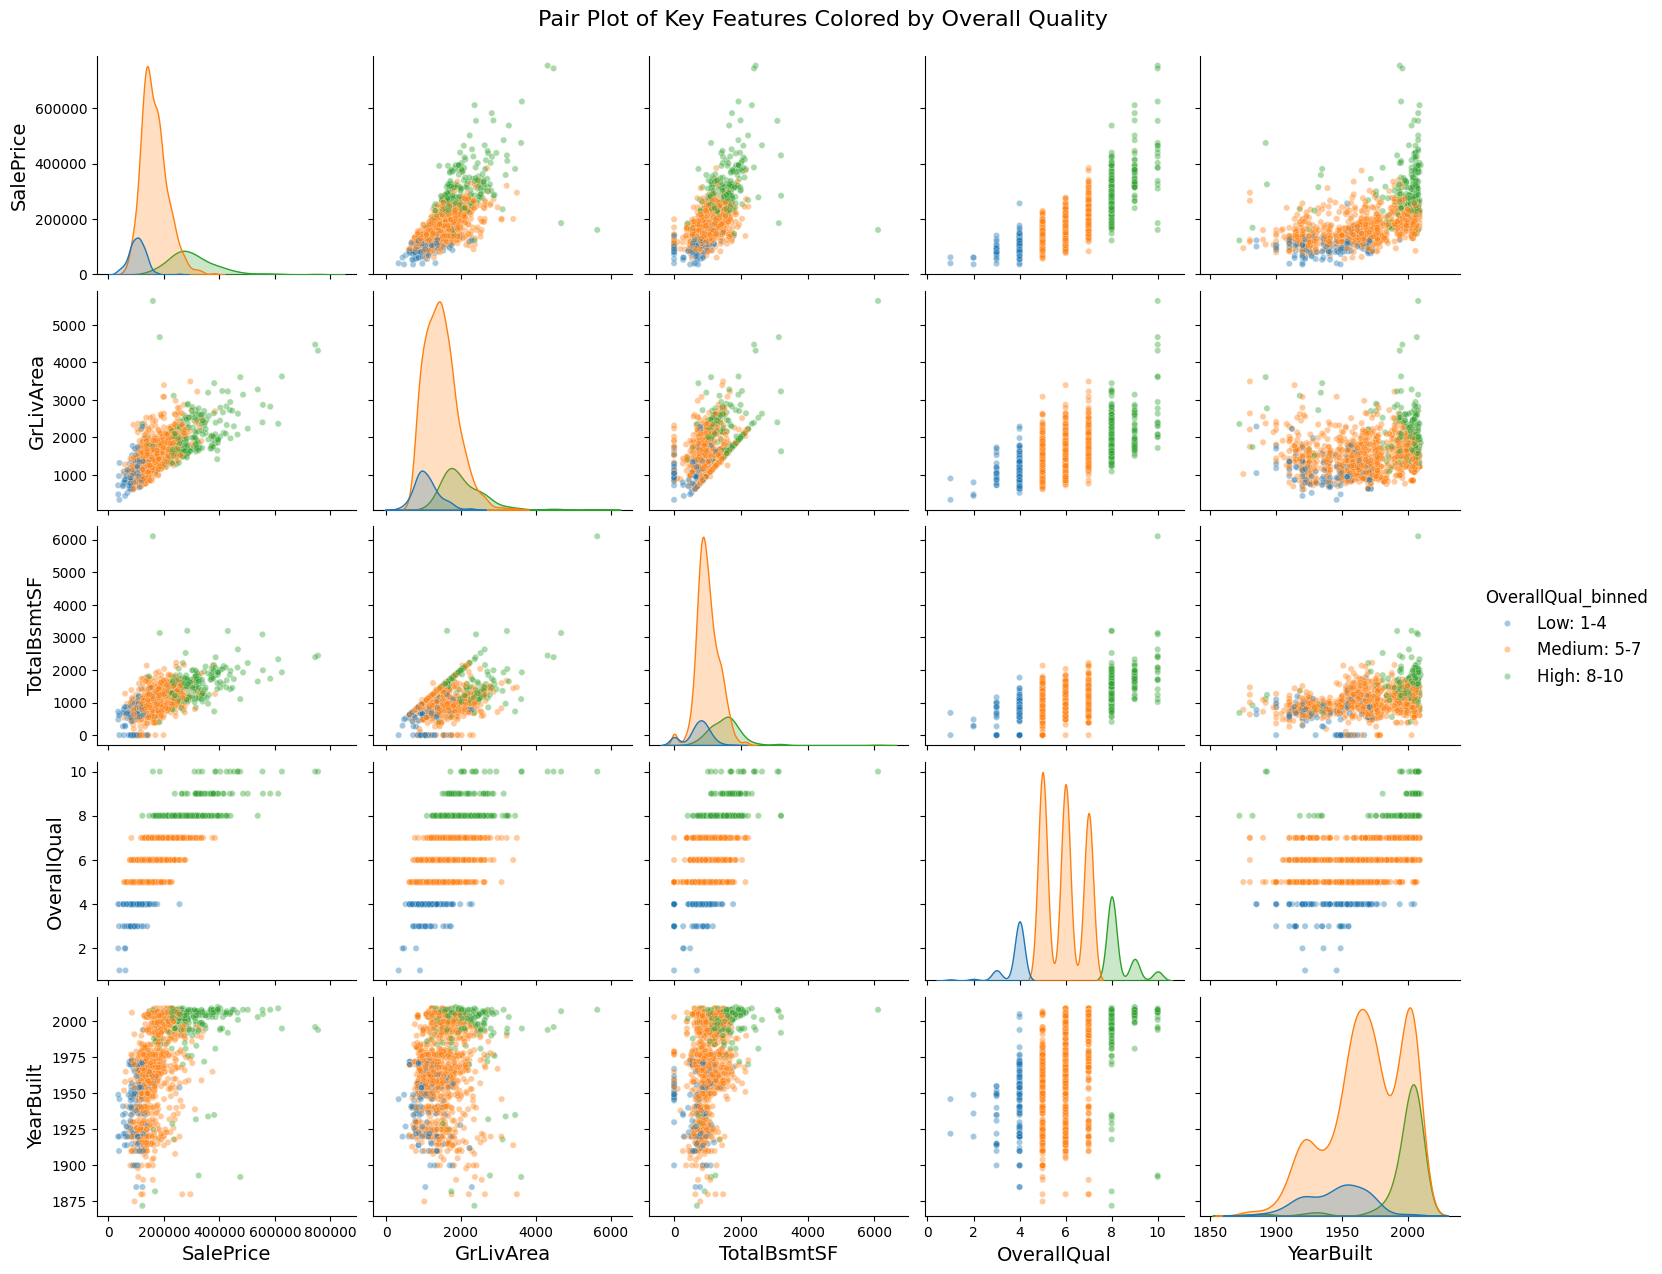

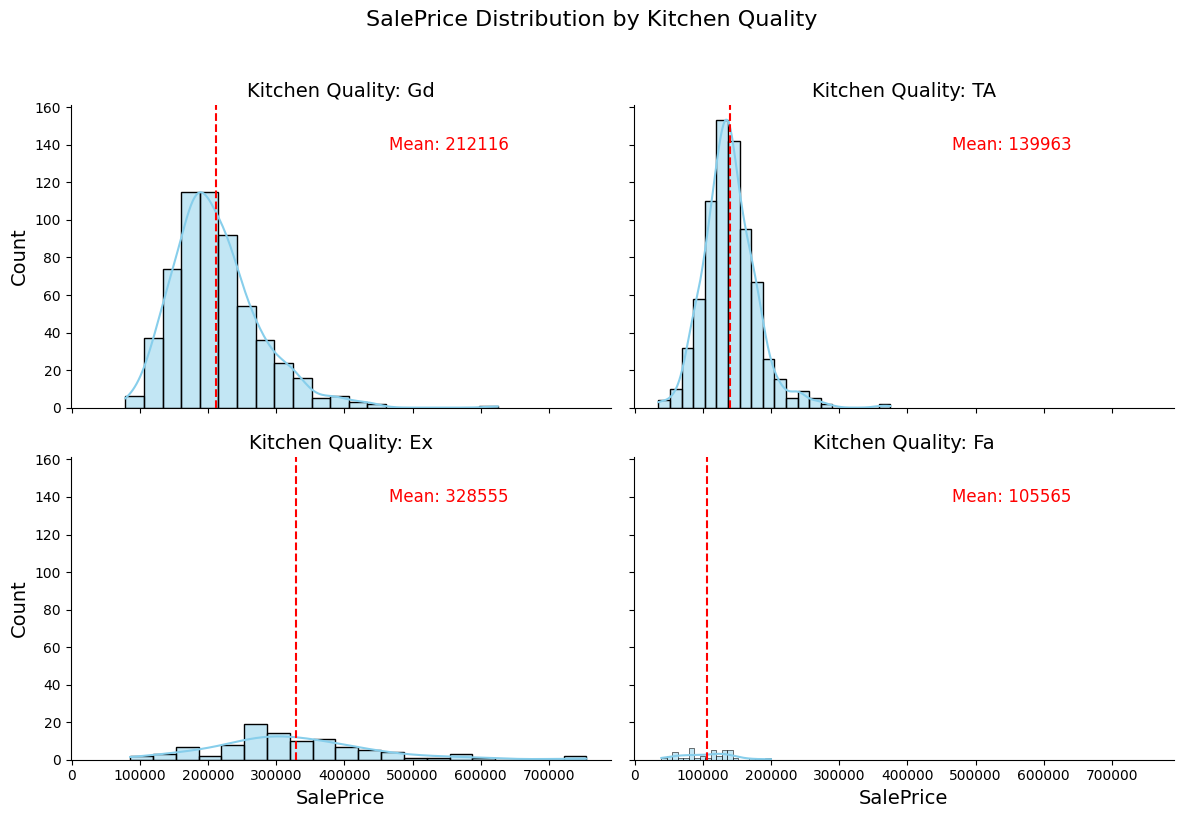

In [11]:
# Chart 7 — sns.pairplot

# Bin OverallQual for coloring
df['OverallQual_binned'] = pd.cut(df['OverallQual'],
                                  bins=[0, 4, 7, 10],
                                  labels=['Low: 1-4', 'Medium: 5-7', 'High: 8-10'],
                                  right=True,
                                  include_lowest=True)

# Columns for the pair plot
pair_plot_cols = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'OverallQual', 'YearBuilt', 'OverallQual_binned']

# Create the pair plot
sns.pairplot(df[pair_plot_cols],
             hue='OverallQual_binned',
             diag_kind='kde',
             plot_kws=dict(alpha=0.4, s=20),
             height=2.5,
             aspect=1.2)

plt.suptitle('Pair Plot of Key Features Colored by Overall Quality', y=1.02, fontsize=16)
plt.savefig('w3_pairplot.png', dpi=300)
plt.show()

# Chart 8 — sns.FacetGrid

# Create a FacetGrid for KitchenQual
g = sns.FacetGrid(df, col='KitchenQual', col_wrap=2, height=4, aspect=1.5, palette='viridis')

# Map a histogram of SalePrice to each facet
g.map(sns.histplot, 'SalePrice', bins=20, kde=True, color='skyblue')

# Add mean line and text annotation to each facet
def add_mean_line(x, **kwargs):
    ax = plt.gca()
    mean_val = x.mean()
    ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.0f}')
    ax.text(0.7, 0.9, f'Mean: {mean_val:.0f}', transform=ax.transAxes, color='red', ha='center', va='top')
    ax.legend()

g.map(add_mean_line, 'SalePrice')

g.set_axis_labels('SalePrice', 'Count')
g.set_titles('Kitchen Quality: {col_name}')
plt.suptitle('SalePrice Distribution by Kitchen Quality', y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig('w3_facetgrid.png', dpi=300)
plt.show()

# Drop the temporary column
df.drop(columns=['OverallQual_binned'], inplace=True)

### Step 3: Matplotlib Chart 3 — Multi-Variable Scatter Plot

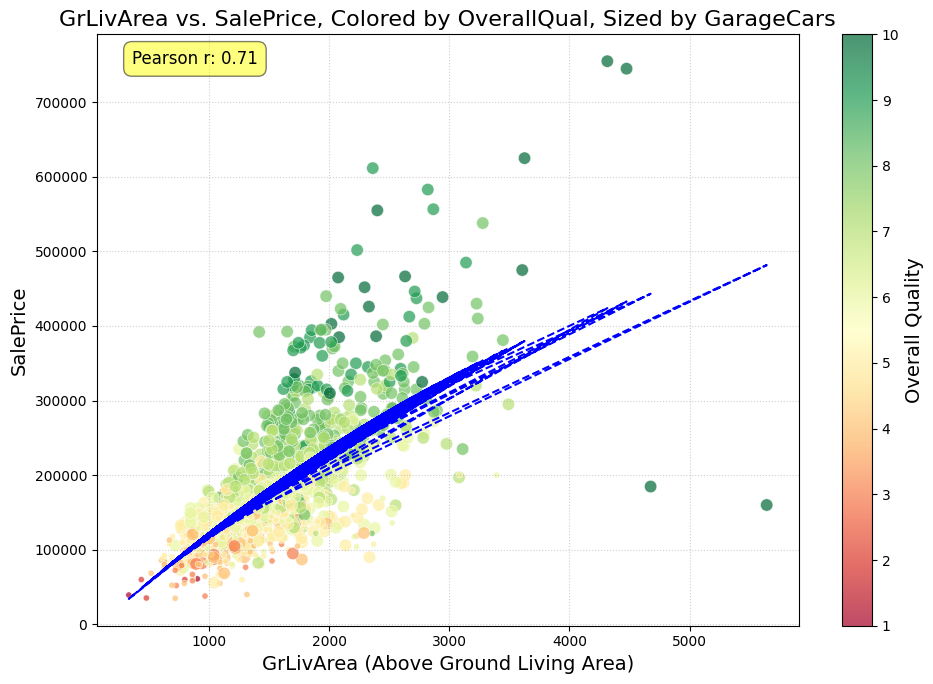

In [13]:
# Chart 3 — Multi-Variable Scatter Plot
plt.figure(figsize=(10, 7))

# Prepare data for sizing, filling NaN values for GarageCars
df['GarageCars_filled'] = df['GarageCars'].fillna(0)

# Create the scatter plot
scatter = plt.scatter(
    x=df['GrLivArea'],
    y=df['SalePrice'],
    c=df['OverallQual'],
    cmap='RdYlGn', # Red-Yellow-Green colormap
    s=df['GarageCars_filled'].apply(lambda x: 20 if x <= 1 else 80), # Size points by GarageCars: small=20 (0-1 car), large=80 (2+ cars)
    alpha=0.7,
    edgecolor='w',
    linewidth=0.5,
    label='_nolegend_'
)

# Add a colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Overall Quality')

# Add polynomial regression line (degree=2)
z = np.polyfit(df['GrLivArea'], df['SalePrice'], 2)
p = np.poly1d(z)
plt.plot(df['GrLivArea'], p(df['GrLivArea']), color='blue', linestyle='--', label='Polynomial Regression (Degree 2)')

# Annotate with Pearson correlation coefficient
pearson_corr = df['GrLivArea'].corr(df['SalePrice'])
plt.annotate(
    f'Pearson r: {pearson_corr:.2f}',
    xy=(0.05, 0.95),
    xycoords='axes fraction',
    fontsize=12,
    color='black',
    bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5)
)

# Add axis labels and title
plt.xlabel('GrLivArea (Above Ground Living Area)')
plt.ylabel('SalePrice')
plt.title('GrLivArea vs. SalePrice, Colored by OverallQual, Sized by GarageCars')

# Set facecolor
plt.gca().set_facecolor('white')

# The colorbar already explains OverallQual, so an explicit legend for 'Low/High Quality' is redundant and caused a warning.
# If a custom legend for size is needed, it would require separate scatter calls or manual handle creation.

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('w3_multi_variable_scatter.png', dpi=300)
plt.show()

# Clean up the temporary column
df.drop(columns=['GarageCars_filled'], inplace=True)

This single scatter plot effectively encodes four variables simultaneously:

1.  **`GrLivArea` (x-axis):** Represents the living area above ground.
2.  **`SalePrice` (y-axis):** Shows the selling price of the house.
3.  **`OverallQual` (color):** The color of each point indicates the overall material and finish quality of the house. A green hue suggests higher quality, while a red hue indicates lower quality.
4.  **`GarageCars` (size):** The size of each point reflects the capacity of the garage in number of cars (small for 0-1 car, large for 2+ cars).

Additionally, a polynomial regression line helps to visualize the trend between `GrLivArea` and `SalePrice`, and the Pearson correlation coefficient quantifies their linear relationship. This visualization provides a rich understanding of how these key features interact and influence the `SalePrice`.

### Step 2: Matplotlib Chart 1 & 2 — Distribution Analysis

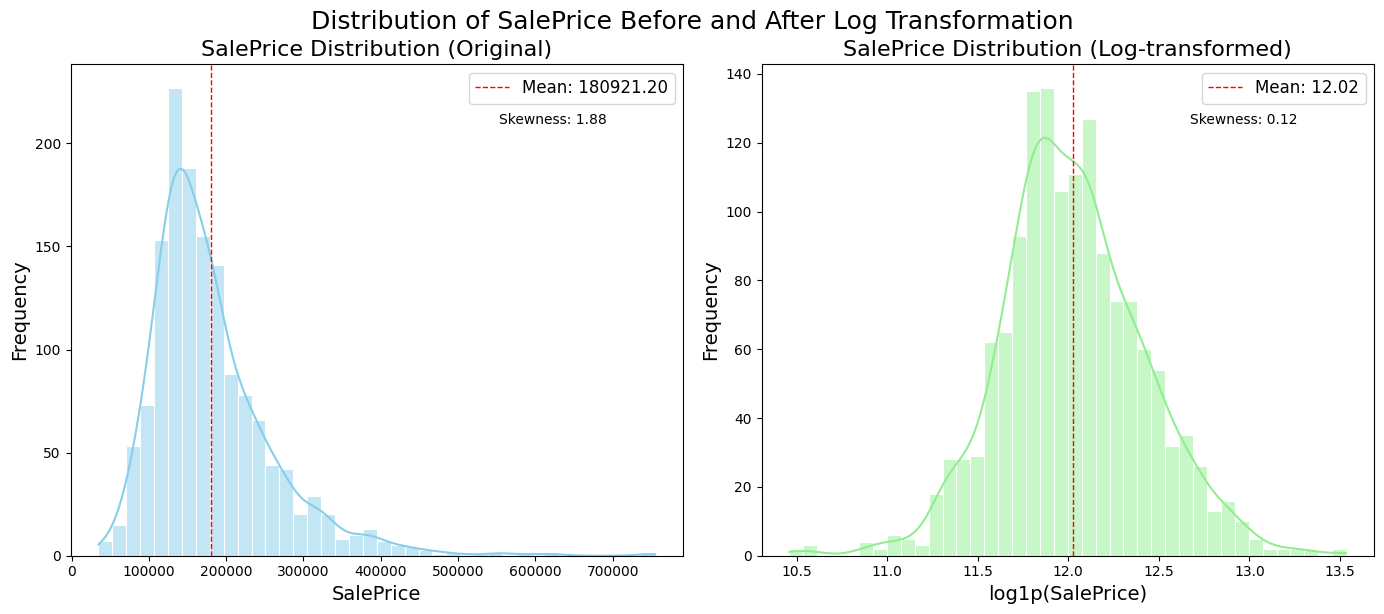

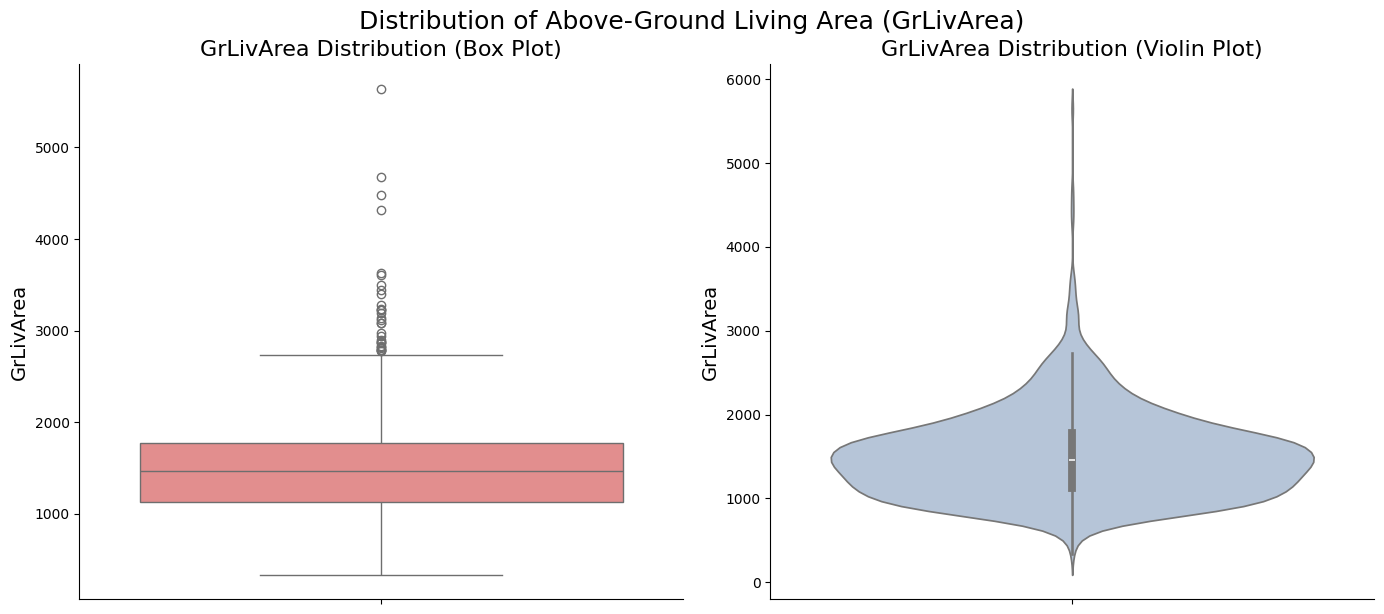

In [7]:
# Chart 1 — SalePrice Distribution
plt.figure(figsize=(14, 6))

# Subplot 1: SalePrice Histogram
plt.subplot(1, 2, 1)
sns.histplot(df['SalePrice'], bins=40, color='skyblue', edgecolor='white', kde=True)
plt.axvline(df['SalePrice'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {df["SalePrice"].mean():.2f}')
skewness_saleprice = df['SalePrice'].skew()
plt.title('SalePrice Distribution (Original)')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.text(0.7, 0.9, f'Skewness: {skewness_saleprice:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.legend()

# Subplot 2: Log-transformed SalePrice Histogram
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['SalePrice']), bins=40, color='lightgreen', edgecolor='white', kde=True)
plt.axvline(np.log1p(df['SalePrice']).mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.log1p(df["SalePrice"]).mean():.2f}')
skewness_log_saleprice = np.log1p(df['SalePrice']).skew()
plt.title('SalePrice Distribution (Log-transformed)')
plt.xlabel('log1p(SalePrice)')
plt.ylabel('Frequency')
plt.text(0.7, 0.9, f'Skewness: {skewness_log_saleprice:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.legend()

plt.tight_layout()
plt.suptitle('Distribution of SalePrice Before and After Log Transformation', y=1.02, fontsize=18)
plt.savefig('w3_saleprice_distribution.png', dpi=300)
plt.show()

# Chart 2 — GrLivArea Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Box plot of GrLivArea
sns.boxplot(y=df['GrLivArea'], ax=axes[0], color='lightcoral')
axes[0].set_title('GrLivArea Distribution (Box Plot)')
axes[0].set_ylabel('GrLivArea')
axes[0].set_facecolor('white')

# Subplot 2: Violin plot of GrLivArea
sns.violinplot(y=df['GrLivArea'], ax=axes[1], color='lightsteelblue')
axes[1].set_title('GrLivArea Distribution (Violin Plot)')
axes[1].set_ylabel('GrLivArea')
axes[1].set_facecolor('white')

# Clean up spines for both subplots
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)

plt.tight_layout()
plt.suptitle('Distribution of Above-Ground Living Area (GrLivArea)', y=1.02, fontsize=18)
plt.savefig('w3_grlivarea_distribution.png', dpi=300)
plt.show()